In [1]:
import os
import numpy as np
import pandas as pd
import json
import systeme as sys
import Allocation
from simulation import simulation
import time

import pickle
import random
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import optuna
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, make_scorer, hamming_loss
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator
from functools import partial

import warnings
#warnings.filterwarnings('ignore')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

instance_name = "az"

c:\Users\e23d691z\Desktop\projets\industrie_nouveau\virtual_environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## generation de data AZ

### recuperation des solutions et des scenarios pour construire les dossiers solution/az_runi et scenarios/az

In [3]:
path = "AZA light/AZA light/"
precount = 0
for i in range(1,5):
    runs_folder = [folder for folder in os.listdir(path) if folder.startswith(f"AZ{i}")]
    folder = runs_folder[0]

    scenario_folder_path = [path+folder+"/"+fol for fol in os.listdir(path+folder) if not fol.endswith(".csv") and not fol.endswith(".txt")][0]
    scenarios_paths = sorted([scenario_folder_path+"/"+scenario for scenario in os.listdir(scenario_folder_path) if scenario.startswith("s")], key=lambda k: int(k.split(".csv")[0].split("s")[1]))
    #enregistrer les scenarios dans le nouveau dossier tout en cumulant et en renommant
    preset_path = "scenarios/az/"
    for scenario in scenarios_paths:
        new_path = preset_path + "s"+str(int(scenario.split("/s")[-1].split(".csv")[0]) + precount)+".csv"
        df = pd.read_csv(scenario, sep=";", header=None)
        df.to_csv(new_path, sep=";", index=None)


    for folder in runs_folder:
        solutions_paths = sorted([path+folder+"/"+filename for filename in os.listdir(path + folder)if filename.startswith("Best")], key=lambda k: int(k.split(".csv")[0].split("_s")[-1]))
        #enregistrer les solutions dans les nouveaux dossiers tout en les cumulant et en les renommant
        preset_path = "solution/az_run"+folder[-1]+"/"
        for solution in solutions_paths:
            new_path = preset_path + "AG_solution_s"+str(int(solution.split("/")[-1].split("_s")[-1].split(".")[0]) + precount)+".csv"
            df = pd.read_csv(solution, sep=";")
            df.to_csv(new_path, sep=";", index=None)

        if len(solutions_paths) != len(scenarios_paths) :
            print(f"probleme nombre de solutions {len(solutions_paths)} pour run {folder} mais nombre de scenarios {len(scenarios_paths)}")
    
    precount += len(solutions_paths)

### construction de az_best

In [ ]:
scenarios = sorted(os.listdir("scenarios/az"), key= lambda k: int(k.split(".")[0][1:]))
solutions = [sorted(os.listdir(f"solution/az_run{i}"), key= lambda k: int(k.split(".")[0].split("n_s")[-1])) for i in range(1,4)]
with open(f'fms/F_5F3C7M_232_3.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
system = sys.systeme(dic)

for scenario_path, solution_path in zip(scenarios, solutions[0]):
    print(scenario_path)
    #initialisation de solution systeme et scenario
    scenario = pd.DataFrame(np.nan_to_num(pd.read_csv("scenarios/az/"+scenario_path,header=None, index_col=None, sep=";"), nan=0)).astype(int).iloc[:,:-1]
    solution = [pd.read_csv(f"solution/az_run{i}/"+solution_path, sep=";", index_col=None, header=None).iloc[:,1:-1] for i in range(1,4)]
    mcts = [simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, sol) for _ in range(len(system.cellules))]).mean_completion_time() for sol in solution]
    pd.read_csv(f"solution/az_run{np.argmin(mcts)+1}/"+solution_path, sep=";").to_csv("solution/az_best/"+solution_path, sep=";", index=None)
    

s1.csv
s2.csv
s3.csv
s4.csv
s5.csv
s6.csv
s7.csv
s8.csv
s9.csv
s10.csv
s11.csv
s12.csv
s13.csv
s14.csv
s15.csv
s16.csv
s17.csv
s18.csv
s19.csv
s20.csv
s21.csv
s22.csv
s23.csv
s24.csv
s25.csv
s26.csv
s27.csv
s28.csv
s29.csv
s30.csv
s31.csv
s32.csv
s33.csv
s34.csv
s35.csv
s36.csv
s37.csv
s38.csv
s39.csv
s40.csv
s41.csv
s42.csv
s43.csv
s44.csv
s45.csv
s46.csv
s47.csv
s48.csv
s49.csv
s50.csv
s51.csv
s52.csv
s53.csv
s54.csv
s55.csv
s56.csv
s57.csv
s58.csv
s59.csv
s60.csv
s61.csv
s62.csv
s63.csv
s64.csv
s65.csv
s66.csv
s67.csv
s68.csv
s69.csv
s70.csv
s71.csv
s72.csv
s73.csv
s74.csv
s75.csv
s76.csv
s77.csv
s78.csv
s79.csv
s80.csv
s81.csv
s82.csv
s83.csv
s84.csv
s85.csv
s86.csv
s87.csv
s88.csv
s89.csv
s90.csv
s91.csv
s92.csv
s93.csv
s94.csv
s95.csv
s96.csv
s97.csv
s98.csv
s99.csv
s100.csv
s101.csv
s102.csv
s103.csv
s104.csv
s105.csv
s106.csv
s107.csv
s108.csv
s109.csv
s110.csv
s111.csv
s112.csv
s113.csv
s114.csv
s115.csv
s116.csv
s117.csv
s118.csv
s119.csv
s120.csv
s121.csv
s122.csv
s123.csv
s

### generation de data pour az

In [3]:
verbose = 1
ds = "az"
scenarios_path_prefixe = f"scenarios/{ds}/"
solutions_path_prefixe = f"solution/{ds}_best/"
with open(f'fms/F_5F3C7M_232_3.json', 'r') as json_file:
    dic = json.load(json_file)
system = sys.systeme(dic)
for scenario_path, solution_path in zip(sorted(os.listdir(scenarios_path_prefixe), key= lambda k : int(k[1:].split(".csv")[0])), sorted(os.listdir(solutions_path_prefixe), key= lambda k : int(k.split(".csv")[0].split("_s")[-1]))):
    if verbose > 0:
        print(f"scenario : {scenario_path}",end="\r")
    #initialisation de solution systeme et scenario
    solution = pd.read_csv(solutions_path_prefixe+solution_path, sep=";", index_col=None, header=None).iloc[:,1:-1]
    scenario = pd.DataFrame(np.nan_to_num(pd.read_csv(scenarios_path_prefixe+scenario_path,header=None, index_col=None, sep=";"), nan=0)).astype(int).iloc[:,:-1]
    sim = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution) for _ in range(len(system.cellules))], saving=True, columns=[], labels_encoded=True)
    logs = sim.get_logs()
    [df.to_csv(f"generated_data/{ds}/single_label/singlelabel_data_sortedlabels_{scenario_path.split(".")[0]}_cell_{i+1}.csv", sep=";", index=False) for df,i in zip(logs, range(len(logs)))]

### generation de data multilabel pour az

In [4]:
def get_voisins(df:pd.DataFrame, line:int, col:int, system:sys.systeme):
    offset = sum([len(x.ressources) for x in system.cellules[:col]])+1
    arr = np.arange(offset,offset+len(system.cellules[col].ressources))
    voisins_locaux = np.delete(arr, np.where(arr == df.iloc[line, col])[0])
    voisins = []
    for voisin in voisins_locaux:
        df_copy = df.copy()
        df_copy.iloc[line, col] = voisin
        voisins.append(df_copy)
    return voisins

def get_echanges(df:pd.DataFrame, line:int, col:int):
    arr_solution = df.values
    valeur_courante = arr_solution[line, col]

    lignes_suivantes = np.arange(line + 1, arr_solution.shape[0])
    valeurs_suivantes = arr_solution[lignes_suivantes, col]

    mask_diff = valeurs_suivantes != valeur_courante
    lignes_differentes = lignes_suivantes[mask_diff]
    valeurs_differentes = valeurs_suivantes[mask_diff]

    if len(lignes_differentes) == 0:
        return []

    echanges_array = np.repeat(arr_solution[np.newaxis, :, :], len(lignes_differentes), axis=0)
    echanges_array[:, line, col] = valeurs_differentes
    echanges_array[np.arange(len(lignes_differentes)), lignes_differentes, col] = valeur_courante

    return [pd.DataFrame(echange, columns=df.columns) for echange in echanges_array]

def upgrade_insert(system:sys.systeme, scenario:pd.DataFrame, solution:pd.DataFrame, stats:dict, verbose:int):
    symetries_indices  = np.empty((solution.shape[0]*solution.shape[1]), dtype=object)
    symetries_indices[:] = [[] for _ in range(solution.shape[0] * solution.shape[1])]
    symetries_indices = symetries_indices.reshape(solution.shape[0], solution.shape[1])
    produit, cellule = 0,0
    upgraded = False
    old_mct = best_mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution) for _ in range(len(system.cellules))]).mean_completion_time()
    while cellule < solution.shape[1]:
        while produit < solution.shape[0]:
            reset = False
            solutions_generees = get_voisins(solution, line=produit, col=cellule, system=system)
            iteration = 0
            for voisin in solutions_generees:
                if verbose > 0:
                    print(f"\tline {produit+1}, col {cellule+1}/{solution.shape[1]}, iteration {iteration+1}/{len(solutions_generees)}                              ",end="\r")
                try:
                    mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, voisin) for _ in range(len(system.cellules))]).mean_completion_time()
                except Exception as e:
                    if verbose >0:
                        print("changement non autorisé : ",e)
                    iteration+=1
                    continue
                if (mct == best_mct):
                    if verbose > 1:
                        print(f"\n\t\tsymetrie produit {produit+1} cell {cellule+1} solution originale {solution.iloc[produit, cellule]} avec solution {voisin.iloc[produit, cellule]}")
                    symetries_indices[produit, cellule].append(iteration)
                    if stats is not None:
                        stats["symetries"][1,cellule] += 1
                elif (mct < best_mct):
                    if verbose > 0:
                        print(f"new best solution found, from {best_mct} to {mct}, redo all")
                    if stats is not None:
                        stats["improvements"] +=1
                    best_mct = mct
                    solution = voisin
                    reset = True
                    upgraded = True
                    if stats is not None:
                        stats["symetries"] = np.zeros_like(stats["symetries"])
                    break
                iteration+=1
            if reset : 
                cellule, produit = 0, 0
                symetries_indices  = np.empty((solution.shape[0]*solution.shape[1]), dtype=object)
                symetries_indices[:] = [[] for _ in range(solution.shape[0] * solution.shape[1])]
                symetries_indices = symetries_indices.reshape(solution.shape[0], solution.shape[1])
            else :
                produit+=1
        cellule+=1
        produit = 0

    return solution, upgraded, old_mct, best_mct, symetries_indices

def upgrade_swap(system:sys.systeme, scenario:pd.DataFrame, solution:pd.DataFrame, stats:dict, verbose:int):
    symetries_indices  = np.empty((solution.shape[0]*solution.shape[1]), dtype=object)
    symetries_indices[:] = [[] for _ in range(solution.shape[0] * solution.shape[1])]
    symetries_indices = symetries_indices.reshape(solution.shape[0], solution.shape[1])
    produit, cellule = 0,0
    upgraded = False
    old_mct = best_mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution) for _ in range(len(system.cellules))]).mean_completion_time()
    while cellule < solution.shape[1]:
        while produit < solution.shape[0]:
            reset = False
            solutions_generees = get_echanges(solution, produit, cellule)
            iteration = 0
            for i in range(len(solutions_generees)):
                if verbose > 0:
                    print(f"\tline {produit+1}, col {cellule+1}/{solution.shape[1]}, iteration {iteration+1}/{len(solutions_generees)}                              ",end="\r")
                try:
                    mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solutions_generees[i]) for _ in range(len(system.cellules))]).mean_completion_time()
                except Exception as e:
                    if verbose > 0 :
                        print("changement non autorisé : ",e)
                    iteration+=1
                    continue
                if (mct == best_mct):
                    if verbose > 1:
                        print(f"\n\t\tsymetrie produit {produit+1} cell {cellule+1} solution originale {solution.iloc[produit, cellule]} avec solution {solutions_generees[i].iloc[produit, cellule]}")
                    symetries_indices[produit, cellule].append(iteration)
                    if stats is not None:
                        stats["symetries"][0,cellule] += 1
                elif (mct < best_mct):
                    if verbose > 0:
                        print(f"\n\t\tnew best solution found, from {best_mct} to {mct}, redo all\n")
                    if stats is not None:
                        stats["improvements"] +=1
                    best_mct = mct
                    solution = solutions_generees[i]
                    reset = True
                    upgraded = True
                    if stats is not None:
                        stats["symetries"] = np.zeros_like(stats["symetries"])
                    break
                iteration+=1

            if reset : 
                cellule, produit = 0, 0
                symetries_indices  = np.empty((solution.shape[0]*solution.shape[1]), dtype=object)
                symetries_indices[:] = [[] for _ in range(solution.shape[0] * solution.shape[1])]
                symetries_indices = symetries_indices.reshape(solution.shape[0], solution.shape[1])
            else :
                produit+=1
        cellule+=1
        produit = 0

    return solution, upgraded, old_mct, best_mct, symetries_indices

def alter_multilabel_dataset_symetries(system:sys.systeme, solution:pd.DataFrame, swapORinsert:int, multilabel_logs:pd.DataFrame, indices_symetrie:np.ndarray, verbose:int):
    for produit in range(indices_symetrie.shape[0]):
        for cellule in range(indices_symetrie.shape[1]):
            if swapORinsert == 0:
                solutions_generees = get_echanges(solution, produit, cellule)
            elif swapORinsert == 1:
                solutions_generees = get_voisins(solution, produit, cellule, system)
            for iteration,i in zip(indices_symetrie[produit,cellule], range(len(indices_symetrie[produit,cellule]))):
                if verbose >0:
                    print(f"\t\tline {produit+1}/{indices_symetrie.shape[0]}, col {cellule+1}/{indices_symetrie.shape[0]}, iteration {i+1}/{len(indices_symetrie[produit,cellule])}",end="\r")
                multilabel_logs[cellule].iloc[produit, solutions_generees[iteration].iloc[produit, cellule]-1 - sum([len(c.ressources) for c in system.cellules][:cellule])-len(system.cellules[cellule].ressources)] = 1  
    return multilabel_logs


In [3]:
verbose = 0
ds = "az"
scenarios_path_prefixe = f"scenarios/{ds}/"
solutions_path_prefixe = f"solution/{ds}_best/"
upgraded_solutions_path_prefixe = f"solution/{ds}_upgraded/"

with open(f'fms/F_5F3C7M_232_3.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
system = sys.systeme(dic)

for scenario_path, solution_path in zip(sorted(os.listdir(scenarios_path_prefixe), key= lambda k : int(k[1:].split(".csv")[0])), sorted(os.listdir(solutions_path_prefixe), key= lambda k : int(k.split(".csv")[0].split("_s")[-1]))):
    if int(scenario_path.split(".")[0][1:])<1419:
        continue
    if verbose > -1:
        print(f"\nscenario : {scenario_path}")
    #initialisation de solution systeme et scenario
    solution = pd.read_csv(solutions_path_prefixe+solution_path, sep=";", index_col=None, header=None).iloc[:,1:-1]
    scenario = pd.DataFrame(np.nan_to_num(pd.read_csv(scenarios_path_prefixe+scenario_path, index_col=None, sep=";"), nan=0)).astype(int).iloc[:,:-1]
    reset = True
    start_time = time.time()
    while reset:
        solution, upgraded, old_mct, new_mct, symetries_indices_swap = upgrade_swap(system, scenario, solution, None, verbose)
        if verbose > 0:
            print(f"\n\n\tswap improved ? {upgraded} " + (f"from {old_mct} to {new_mct}" if upgraded else f" with {old_mct}"))
        solution, upgraded, old_mct, new_mct, symetries_indices_insert = upgrade_insert(system, scenario, solution, None, verbose)
        if verbose > 0:
            print(f"\n\n\tinsert improved ? {upgraded} " + (f"from {old_mct} to {new_mct}" if upgraded else f" with {old_mct}"))
        reset = upgraded
    # arrivés là on est surs d'avoir la meilleure solution non ameliorable dans solution, on sauvegarde la solution
    solution.insert(0, None, [f"P{i+1}" for i in range(len(solution))])
    solution[len(solution.columns)] = 0
    solution.to_csv(upgraded_solutions_path_prefixe+solution_path, sep=";", index=False, header=False)

    # symetries
    if verbose > 0:
        print(f"\n\t meilleure solution trouvée, début traitement symétries\n")
    base_logs = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution.iloc[:,1:-1]) for _ in range(len(system.cellules))], saving=True).get_logs()
    expected_classes = [
        [0, 1],    # à changer, c'est le nombre de ressources par cellule
        [0, 1, 2], 
        [0, 1]     
    ]

    # Transformation de base_logs
    multilabel_logs = []
    for i, base_log in enumerate(base_logs):
        selected_column = base_log.columns[-1]
        dummies = pd.get_dummies(base_log, columns=[selected_column], drop_first=False, dtype=int)

        # S'assurer que toutes les colonnes attendues sont présentes
        for cls in expected_classes[i]:
            col_name = selected_column +"_"+ str(cls)+".0"
            if col_name not in dummies.columns:
                dummies[col_name] = 0  # Ajouter la colonne si elle est absente

        # Réorganiser l'ordre des colonnes
        cols = list(base_log.columns[:-1]) + [selected_column +"_"+ str(cls)+".0" for cls in expected_classes[i]]
        dummies = dummies[cols]  
        
        new_base_log = dummies
        
        multilabel_logs.append(new_base_log)

    for cell_log, i in zip(multilabel_logs, range(len(multilabel_logs))): # solution opti locale sans symetries
        cell_log.to_csv(f"generated_data/{ds}/multilabel/none/multilabel_data_original_{scenario_path.split(".")[0]}_cell_{i + 1}.csv", sep=";", index=None)

    multilabel_logs_swap = alter_multilabel_dataset_symetries(system, solution.iloc[:,1:-1], 0, multilabel_logs, symetries_indices_swap, verbose)
    for cell_log, i in zip(multilabel_logs_swap, range(len(multilabel_logs_swap))): # avec swap seul
        cell_log.to_csv(f"generated_data/{ds}/multilabel/swap/multilabel_data_swap_{scenario_path.split(".")[0]}_cell_{i + 1}.csv", sep=";", index=None)
    
    base_logs = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution.iloc[:,1:-1]) for _ in range(len(system.cellules))], saving=True).get_logs()
    multilabel_logs_insert = alter_multilabel_dataset_symetries(system, solution.iloc[:,1:-1], 1, multilabel_logs, symetries_indices_insert, verbose)  
    for cell_log, i in zip(multilabel_logs_insert, range(len(multilabel_logs_insert))): # avec insert seul
        cell_log.to_csv(f"generated_data/{ds}/multilabel/insert/multilabel_data_insert_{scenario_path.split(".")[0]}_cell_{i + 1}.csv", sep=";", index=None)


scenario : s1419.csv

scenario : s1420.csv

scenario : s1421.csv

scenario : s1422.csv

scenario : s1423.csv

scenario : s1424.csv

scenario : s1425.csv

scenario : s1426.csv

scenario : s1427.csv

scenario : s1428.csv

scenario : s1429.csv

scenario : s1430.csv

scenario : s1431.csv

scenario : s1432.csv

scenario : s1433.csv

scenario : s1434.csv

scenario : s1435.csv

scenario : s1436.csv

scenario : s1437.csv

scenario : s1438.csv

scenario : s1439.csv

scenario : s1440.csv

scenario : s1441.csv

scenario : s1442.csv

scenario : s1443.csv

scenario : s1444.csv

scenario : s1445.csv

scenario : s1446.csv

scenario : s1447.csv

scenario : s1448.csv

scenario : s1449.csv

scenario : s1450.csv

scenario : s1451.csv

scenario : s1452.csv

scenario : s1453.csv

scenario : s1454.csv

scenario : s1455.csv

scenario : s1456.csv

scenario : s1457.csv

scenario : s1458.csv

scenario : s1459.csv

scenario : s1460.csv

scenario : s1461.csv

scenario : s1462.csv

scenario : s1463.csv

scenario 

In [4]:
# R1 et R2 dans la meme cellule  ---
# R1 tps setup R2 tps setup   ---
# R1 tps process R2 tps process  ---
# R1 pred_fam == R2 pred_fam 
# R1 current charge == R2 current charge


# 1 localliser les ressources identiques dans systeme pour chaque cellule
ds = "az"
data_path_prefixe = f"generated_data/{ds}/multilabel/none/"
data_path_save = f"generated_data/{ds}/multilabel/machine_id/"
with open(f'fms/F_5F3C7M_232_3.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
system = sys.systeme(dic)
nb_symetries = {}
nb_cells = len(system.cellules)
identiques = []
for c in system.cellules:
    ids_cell = []
    for r in c.ressources:
        ids_ress = []
        for r2 in c.ressources:
            if r is r2 or (r.processTimes == r2.processTimes and r.setupTimes == r2.setupTimes) :
                ids_ress.append(True)
            else :
                ids_ress.append(False)
        ids_cell.append(ids_ress)
    identiques.append(ids_cell)
identical_couples = [[(i+1, j+1) for i, j in np.argwhere((np.array(idd).astype(int) == 1) & np.triu(np.ones(np.array(idd).astype(int).shape, dtype=bool), k=1))] for idd in identiques]
cell_containing_identities = np.where(np.array([int(np.sum(x)/len(x)) for x in identiques]) != 1)[0]

# 2 pour chaque dataset d'un scenario et d'une cellule contenant des identités
for dataset_path in os.listdir(data_path_prefixe):
    if dataset_path.endswith("json"):
        continue
    print(f"\nscenario {dataset_path.split("_cell")[0].split("_s")[-1]} :")
    cell = int(dataset_path[:-4].split("_")[-1]) -1

    nb_symetries[f"s{dataset_path.split("_cell")[0].split("_s")[-1]}.csv"] = nb_symetries.get(f"s{dataset_path.split("_cell")[0].split("_s")[-1]}.csv", [0]*nb_cells)
    if cell in cell_containing_identities:
        print(f"\tcellule {cell+1} :")
        dataset = pd.read_csv(data_path_prefixe+dataset_path, sep=";", index_col=None)
        
        # 3 trouver les colonnes a verifier
        for line in range(dataset.shape[0]):
            for couple in identical_couples[cell]:
                # 4 verifier les conditions
                if dataset["predFamilies_R"+str(couple[0])][line] == dataset["predFamilies_R"+str(couple[1])][line]  and  dataset["Cur_Charge_comparable_R"+str(couple[0])][line] == dataset["Cur_Charge_comparable_R"+str(couple[1])][line] \
                and  ((dataset[f"Selected Resource_{couple[0]-1}.0"][line] + dataset[f"Selected Resource_{couple[1]-1}.0"][line]) == 1):
                    print("\t\tsymetrie ligne : ", line)
                    nb_symetries[f"s{dataset_path.split("_cell")[0].split("_s")[-1]}.csv"][cell] += 1
                    # 5 succes, symetrie detectee rajouter les annotations
                    dataset.loc[line, f"Selected Resource_{couple[0]-1}.0"] = 1
                    dataset.loc[line, f"Selected Resource_{couple[1]-1}.0"] = 1

        # 6 sauvegarder le dataframe
        dataset.to_csv(data_path_save+dataset_path, sep=";", index=None)

#   2   3   2



scenario 1000 :
	cellule 1 :

scenario 1000 :

scenario 1000 :

scenario 1001 :
	cellule 1 :

scenario 1001 :

scenario 1001 :

scenario 1002 :
	cellule 1 :

scenario 1002 :

scenario 1002 :

scenario 1003 :
	cellule 1 :

scenario 1003 :

scenario 1003 :

scenario 1004 :
	cellule 1 :

scenario 1004 :

scenario 1004 :

scenario 1005 :
	cellule 1 :

scenario 1005 :

scenario 1005 :

scenario 1006 :
	cellule 1 :

scenario 1006 :

scenario 1006 :

scenario 1007 :
	cellule 1 :

scenario 1007 :

scenario 1007 :

scenario 1008 :
	cellule 1 :

scenario 1008 :

scenario 1008 :

scenario 1009 :
	cellule 1 :

scenario 1009 :

scenario 1009 :

scenario 100 :
	cellule 1 :

scenario 100 :

scenario 100 :

scenario 1010 :
	cellule 1 :

scenario 1010 :

scenario 1010 :

scenario 1011 :
	cellule 1 :

scenario 1011 :

scenario 1011 :

scenario 1012 :
	cellule 1 :

scenario 1012 :

scenario 1012 :

scenario 1013 :
	cellule 1 :

scenario 1013 :

scenario 1013 :

scenario 1014 :
	cellule 1 :

scenario 101

#### concatenage des multilabel en un dataset final multilabel

In [15]:
destination_path = "generated_data/az/multilabel/final/"
source_none_path = "generated_data/az/multilabel/none/"
source_swap_path = "generated_data/az/multilabel/swap/"
source_insert_path = "generated_data/az/multilabel/insert/"
source_mid_path = "generated_data/az/multilabel/machine_id/"

swap_files = [source_swap_path+f for f in os.listdir(source_swap_path)]
insert_files = [source_insert_path+f for f in os.listdir(source_insert_path)]
mid_files = [source_mid_path+f for f in os.listdir(source_mid_path)]



nb_cells = 3
nb_scenarios = 3000

for c in range(1,1+nb_cells):
    for scen in range(1,nb_scenarios+1):
        df_swap = pd.read_csv(source_swap_path+f"multilabel_data_swap_s{scen}_cell_{c}.csv", sep=";")
        df_insert = pd.read_csv(source_insert_path+f"multilabel_data_insert_s{scen}_cell_{c}.csv", sep=";")
        if source_mid_path+f"multilabel_data_original_s{scen}_cell_{c}.csv" in mid_files:
            df_mid = pd.read_csv(source_mid_path+f"multilabel_data_original_s{scen}_cell_{c}.csv", sep=";")
        else:
            df_mid = pd.read_csv(source_none_path+f"multilabel_data_original_s{scen}_cell_{c}.csv", sep=";")
        
        df_final = df_swap.copy()
        selected_cols = [col for col in df_final.columns if col.startswith("Selected")]
        df_final[selected_cols] = (df_swap[selected_cols] + df_insert[selected_cols] + df_mid[selected_cols]).clip(upper=1)
        
        df_final.to_csv(destination_path+f"multilabel_data_s{scen}_cell_{c}.csv", sep=";", index=None)

In [14]:
# adding columns to encode 

source_path = "generated_data/az/multilabel/final/"
destination_path = "generated_data/az/multilabel/final_encoded/"

nb_cells = 3
nb_scenarios = 3000

for c in range(1,1+nb_cells):
    for scen in range(1,nb_scenarios+1):
        df = pd.read_csv(source_path+f"multilabel_data_s{scen}_cell_{c}.csv", sep=";")
        
         # Step 1: Identify relevant columns
        charge_cols = [col for col in df.columns if col.startswith("Cur_Charge_comparable_R")]
        label_cols = [col for col in df.columns if col.startswith("Selected Resource_")]

        # Step 2: Get resource label mapping from column names
        # Map "Selected Resource_0.0" → 0, etc.
        label_indices = [int(float(col.split("_")[-1])) for col in label_cols]
        label_map = dict(zip(label_cols, label_indices))  # e.g. {"Selected Resource_0.0": 0, ...}
        label_cols_sorted = [col for _, col in sorted(zip(label_indices, label_cols))]

        num_ressources = len(charge_cols)

        # Step 3: Process row by row
        encoded_cols = []
        for i in range(num_ressources):
            encoded_cols.append(f"Selected_Resource_encoded_{i}")
            df[f"Selected_Resource_encoded_{i}"] = 0  # initialize

        for idx, row in df.iterrows():
            # Get current charges and compute sorted order of resource indices
            charges = [row[col] for col in charge_cols]
            sorted_indices = np.argsort(charges)  

            # Identify which resource(s) were selected
            selected = [i for i, col in enumerate(label_cols_sorted) if row[col] == 1]

            for i, res_idx in enumerate(sorted_indices):
                if res_idx in selected:
                    df.at[idx, f"Selected_Resource_encoded_{i}"] = 1

        # Step 4: Save final file
        df.drop(columns=label_cols, inplace=True)
        os.makedirs(destination_path, exist_ok=True)
        df.to_csv(destination_path+f"multilabel_data_s{scen}_cell_{c}.csv", sep=";", index=None)

## entrainement des modeles

### data preparation

In [2]:
def calcul_gap(modele, scaler, cellule, scenarios):
    scenarios_path = f"scenarios/K0"
    solution_path = f"solution/K0_best//"
    
    with open(f'fms/3C7R5F.json', 'r') as json_file: #5C14R5F #3C7R5F
        dic = json.load(json_file)
    s = sys.systeme(dic)
    all_gaps = []
    for f in os.listdir(scenarios_path):
        if int(f.split(".")[0][1:]) not in scenarios:
            continue
        df = pd.DataFrame(np.nan_to_num(pd.read_csv(f"{scenarios_path}/"+f,header=None, index_col=None, sep=";"), nan=0)).astype(int)
        own_sol_path_list = [file for file in os.listdir(solution_path) if file.split(".")[0][-len(f.split(".")[0]):] == f.split(".")[0]]
        if len(own_sol_path_list) == 0:
            continue
        sol_path = own_sol_path_list[0]
        sol = pd.read_csv(solution_path+sol_path, sep=";", index_col=None, header=None).iloc[:,1:-1]

        allocators = [Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol)]
        ref_mct = simulation(system=s, scenario=df, allocators=allocators).mean_completion_time()
        allocators[cellule-1] = Allocation.DynamicAllocator(s, modele, scaler, to_categorical=True)
        mct = simulation(system=s, scenario=df, allocators=allocators).mean_completion_time()
        gap = (100*(mct - ref_mct)/ref_mct)
        all_gaps.append(gap)

    return np.mean(all_gaps)

def callback(_, trial, cell, X_train, Y_train, scaler, scenarios_test, scores, cv):
    current_params = trial.params
    current_model = RandomForestClassifier(**current_params, random_state=RANDOM_SEED)
    current_model.fit(X_train, Y_train)

    #current_gap = calcul_gap(current_model, scaler, cell, scenarios_test)
    acc = cross_val_score(current_model, X_train, Y_train, cv=cv, scoring=make_scorer(element_wise_accuracy_rf)).mean()
    scores.append(acc)
    #scores.append([current_gap, acc])
    
def plot_convergence(study, scores):
    if type(scores[0]) is list:
        both = True
        gaps = [score[0] for score in scores]
        accs = [score[1] for score in scores]
    else :
        both = False
        accs = scores


    plt.figure(figsize=(20, 6))  # Augmentation de la largeur pour le troisième subplot

    if both:
        cumulative_max = np.minimum.accumulate(gaps)  # Best mct
        # Subplot 1 : Évolution de mct
        plt.subplot(1, 3, 1)
        plt.plot(gaps, label="mct", marker="o")
        plt.plot(cumulative_max, label="Best mct", color="orange", linestyle="dashed", marker="x")
        plt.title("Évolution de MCT lors du tuning")
        plt.xlabel("Essais (Trials)")
        plt.ylabel("Moyenne MCT")
        plt.grid()
        plt.legend()

    # Récupération des valeurs de accuracy
    cumulative_max_accuracy = np.maximum.accumulate(accs)

    # Subplot 2 : Évolution de accuracy
    plt.subplot(1, 3, 2)
    plt.plot(accs, label="accuracy", marker="o")
    plt.plot(cumulative_max_accuracy, label="Best accuracy", color="orange", linestyle="dashed", marker="x")
    plt.title("Évolution de l'accuracy lors du tuning")
    plt.xlabel("Essais (Trials)")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.legend()

    if both:
        # Subplot 3 : Nuage de points MCT vs Accuracy
        plt.subplot(1, 3, 3)
        plt.scatter(accs, gaps, color="blue", alpha=0.6)
        plt.title("Relation entre MCT et Accuracy")
        plt.xlabel("Accuracy")
        plt.ylabel("MCT")
        plt.grid()

    plt.tight_layout()
    plt.show()

def element_wise_accuracy_rf(y_true, y_pred):
    # Convertir en numpy array pour éviter les conflits avec pandas
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float((y_true == y_pred).mean())

def objective_rf(trial, X_train, y_train, cv=3, scenarios_test=None, scaler=None, cell=None):
    """
    Fonction objectif pour optimiser les hyperparamètres d'un Random Forest avec Optuna.
    """
    # Définir les hyperparamètres à optimiser
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Initialiser le modèle avec les hyperparamètres
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_SEED
    )

    # Effectuer une validation croisée pour évaluer la performance

    model.fit(X_train, y_train)

    #return  -calcul_gap(model, scaler, cell, scenarios_test)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=make_scorer(element_wise_accuracy_rf))
    return scores.mean()  # Retourner la moyenne des scores comme métrique

def train_random_forest_with_optuna(X_train, y_train, X_test, y_test, scaler, max_trials=49, alpha=50, beta=0.1, patience_limit=1, random_seed=RANDOM_SEED, cell=1, scenarios_test=[]):
    """
    Entraîner un Random Forest optimisé via une recherche bayésienne sur les hyperparamètres.
    """
    # Initialiser une étude Optuna
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=random_seed))
    total_trials = 0
    remaining_trials = alpha  # Nombre initial de trials
    step = 0
    best_known_score = 0
    patience = 0
    scores = []

    custom_callback = partial(callback, X_train=X_train, Y_train=y_train, scenarios_test=scenarios_test, scores=scores, cell=cell, scaler=scaler, cv=3)

    while total_trials < max_trials and patience < patience_limit:
        print(f"Optimizing: Step {step + 1}, Remaining trials: {remaining_trials}")
        study.optimize(lambda trial: objective_rf(trial, X_train, y_train, cv=3, scenarios_test=scenarios_test, scaler=scaler, cell=cell), n_trials=remaining_trials, callbacks=[custom_callback])
        
        remaining_trials = int(np.ceil(alpha / (1 + beta * step)))
        total_trials += remaining_trials
        step += 1

        best_current_score = study.best_value

        if best_current_score > best_known_score:
            best_known_score = best_current_score
            patience = 0 
        else:
            patience += 1  

    # Afficher les meilleurs paramètres trouvés
    best_params = study.best_params
    print(f"Best Hyperparameters: {best_params}")

    # Entraîner le modèle avec les meilleurs hyperparamètres
    model = RandomForestClassifier(**best_params, random_state=random_seed)
    model.fit(X_train, y_train)

    # Prédire sur le jeu de test et afficher les performances
    predictions = model.predict(X_test)
    print("Optimized Random Forest - Classification Report:")
    print(classification_report(y_test, predictions))

    plot_convergence(study, scores)

    return model, best_params


In [3]:
with open(f'fms/F_5F3C7M_232_3.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
s = sys.systeme(dic)

instance_name = "az"
data_folder_path = f"generated_data/az/multilabel/final_encoded/" # final_encoded
total_nb_scenarios = 3000 * 3
test_scenario_count = 500

file_names_per_cell, columns_per_cell, dfs_train, dfs_test = [],[],[],[]


for cell,c in zip(s.cellules,range(len(s.cellules))):
    file_names_per_cell.append([file for file in os.listdir(data_folder_path)[:total_nb_scenarios] if file.endswith(f"cell_{c+1}.csv")])
    kept_cols = cell.header[:-1]
    columns_per_cell.append(kept_cols)
    
    if c == 0:
        test_split = list(range(1, len(file_names_per_cell[0])+1))
        random.shuffle(test_split)
        test_split = test_split[:test_scenario_count]
        test_split_scenarios = test_split[:len(test_split)]
        train_split_scenarios = [file for file in list(range(1,len(file_names_per_cell[0])+1)) if file not in test_split]

    paths = sorted([data_folder_path+"/"+x for x in os.listdir(data_folder_path) if x.endswith(f"{c+1}.csv")], key= lambda k: int(k.split("_cell_")[0].split("s")[-1]))

    filtered_dfs_train = [pd.read_csv(paths[scenar-1], delimiter=";") for scenar in train_split_scenarios]
    filtered_dfs_test = [pd.read_csv(paths[scenar-1], delimiter=";") for scenar in test_split_scenarios]
    

    df_train = pd.concat(filtered_dfs_train, ignore_index=True)
    df_train.fillna(0, inplace=True)


    categorical_cols = [col for col in df_train.columns if col.startswith("Family")]
    to_delete_cols = [col+"_0" for col in df_train.columns if col.startswith("Family")]  
    last_col = [col for col in df_train.columns if col.startswith("Selected")]
    categorical_spec = {
        "Family": [1, 2, 3, 4, 5]
        }
    new_columns = []
    for prefix, unique_values in categorical_spec.items():
        cols_to_encode = [col for col in df_train.columns if col.startswith(prefix)]
        for col in cols_to_encode:
            for value in unique_values:
                new_col_name = f"{col}_{value}"
                new_columns.append(pd.DataFrame({new_col_name: (df_train[col] == value).astype(float)}))
    df_train = pd.concat([df_train] + new_columns, axis=1)       
    df_train.drop(columns=to_delete_cols, inplace=True, errors='ignore')
    df_train.drop(columns=categorical_cols, inplace=True, errors='ignore')

    colus = df_train.columns.tolist()
    for col in last_col:
        colus.remove(col)
        df_train = df_train[colus + [col]]
        colus.append(col)
    
    no_label_cols = [col for col in df_train.columns if not col.startswith("Selected")]
    label_cols = [col for col in df_train.columns if col.startswith("Selected")]

    dfs_train.append(df_train.astype(float))



    df_test = pd.concat(filtered_dfs_test, ignore_index=True)
    df_test.fillna(0, inplace=True)

    new_columns = []
    for prefix, unique_values in categorical_spec.items():
        cols_to_encode = [col for col in df_test.columns if col.startswith(prefix)]
        for col in cols_to_encode:
            for value in unique_values:
                new_col_name = f"{col}_{value}"
                new_columns.append(pd.DataFrame({new_col_name: (df_test[col] == value).astype(float)}))
    df_test = pd.concat([df_test] + new_columns, axis=1)
    df_test.drop(columns=to_delete_cols, inplace=True, errors='ignore')
    df_test.drop(columns=categorical_cols, inplace=True, errors='ignore')

    colus = df_test.columns.tolist()
    for col in last_col:
        colus.remove(col)
        df_test = df_test[colus + [col]]
        colus.append(col)

    dfs_test.append(df_test.astype(float))


### models training

[I 2025-05-12 06:37:47,315] A new study created in memory with name: no-name-f08f1ddc-c768-4bf5-90e2-037550c75906



Processing dataset 3...

Number of ressources 2...
Optimizing: Step 1, Remaining trials: 50


[I 2025-05-12 06:38:03,343] Trial 0 finished with value: 0.9181109310084382 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9181109310084382.
[I 2025-05-12 06:38:49,954] Trial 1 finished with value: 0.9184048808183588 and parameters: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9184048808183588.
[I 2025-05-12 06:39:35,286] Trial 2 finished with value: 0.9138009757887421 and parameters: {'n_estimators': 95, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 11, 'max_features': None}. Best is trial 1 with value: 0.9184048808183588.
[I 2025-05-12 06:39:57,326] Trial 3 finished with value: 0.9160800314320787 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.918404880818358

Best Hyperparameters: {'n_estimators': 213, 'max_depth': 12, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
Optimized Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     13517
           1       0.93      0.90      0.91     13371

   micro avg       0.92      0.92      0.92     26888
   macro avg       0.93      0.92      0.92     26888
weighted avg       0.93      0.92      0.92     26888
 samples avg       0.93      0.93      0.93     26888



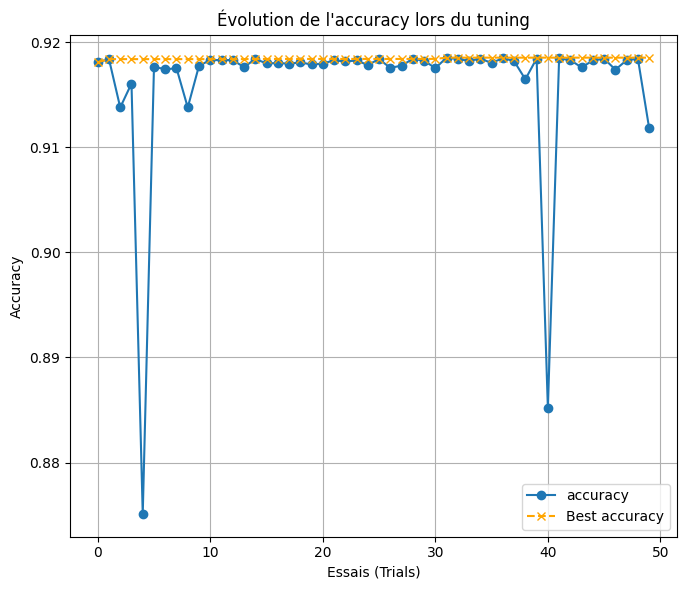

Validation Performance for dataset 3:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     13517
           1       0.93      0.90      0.91     13371

   micro avg       0.92      0.92      0.92     26888
   macro avg       0.93      0.92      0.92     26888
weighted avg       0.93      0.92      0.92     26888
 samples avg       0.93      0.93      0.93     26888

(25948, 2) (25948, 2)
Accuracy: 0.9187605981193155
Hamming Score: 0.9187605981193155
calculated accuracy based on top probability only:0.9350238939417296
- - - saving - - -


In [8]:
#training (les deux datasets le meme code, changer juste point rouge)

nn_models, rf_models, xgb_models= [], [], []
model_type = "rf" # "rf" "xgboost" "nn"

c=2
for i, (train_df, test_df) in enumerate(zip(dfs_train, dfs_test)):
    if i < c:
        continue
    c+=1
    print(f"\nProcessing dataset {i+1}...")
    nb_classes = len([col for col in train_df.columns if col.startswith("Selected")])
    print(f"\nNumber of ressources {nb_classes}...")

    X_train, y_train = train_df.iloc[:, :-nb_classes], train_df.iloc[:, -nb_classes:].map(lambda x: 1 if x > 0 else 0)
    X_test, y_test = test_df.iloc[:, :-nb_classes], test_df.iloc[:, -nb_classes:].map(lambda x: 1 if x > 0 else 0)

    model = train_random_forest_with_optuna(X_train, y_train, X_test, y_test, None, max_trials = 49, alpha= 50, beta = 0.1, random_seed=RANDOM_SEED, scenarios_test=test_split_scenarios,cell=c)
    
    predictions_test = model[0].predict(X_test)
    print(f"Validation Performance for dataset {i+1}:")
    if model_type == "nn":
        predictions_test = np.round(predictions_test)

    print(classification_report(y_test, predictions_test))
    print(y_test.shape, predictions_test.shape)
    accuracy = np.mean(y_test == predictions_test)
    print(f"Accuracy: {accuracy}")
    print(f"Hamming Score: {1 - hamming_loss(y_test, predictions_test)}")
    
    if model_type == "nn":
        predicted = np.argmax(model[0].predict(X_test), axis=1)
    elif model_type == "rf":
        predicted = np.argmax(np.column_stack([model[0].predict_proba(X_test)[i][:,1] for i in range(len(model[0].predict_proba(X_test)))]), axis=1)
    count = 0
    for i in range(predicted.shape[0]):
        ress_choice = predicted[i] 
        if y_test.iloc[i, ress_choice] == 1:  
            count += 1
    print(f"calculated accuracy based on top probability only:{count/predicted.shape[0]}")


    print("- - - saving - - -")
    rf_models.append(model[0])
    with open(f"generated_models/az/multiclass/models_cell{c}/encodedcc_standard_RandomForest_{total_nb_scenarios//3}s.pkl", 'wb') as file: #change G for K0
        pickle.dump(model[0], file)
    

## simulation

In [10]:
models= []
for i in range(1,4):
    #with open(f"generated_models/multiclass_added_min/G/models_cell{i}/standard_RandomForest.pkl", 'rb') as f:
    with open(f"generated_models/az/multiclass/models_cell{i}/encodedcc_standard_RandomForest_{total_nb_scenarios//3}s.pkl", 'rb') as f:
        models.append(pickle.load(f))

scenarios_path = f"scenarios/az"
solution_path = f"solution/az_best//"

with open(f'fms/F_5F3C7M_232_3.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
s = sys.systeme(dic)
results = np.zeros((0,4))
reference_results = np.zeros((0,4))

for f in os.listdir(scenarios_path):
    print(f"{f.split(".")[0]}\t:\t", end = "")
    if int(f.split(".")[0][1:]) not in test_split_scenarios:
        print("dans les scenarios d'entrainement",end="\r")
        continue
    df = pd.DataFrame(np.nan_to_num(pd.read_csv(f"{scenarios_path}/"+f, index_col=None, sep=";"), nan=0)).astype(int)
    own_sol_path_list = [file for file in os.listdir(solution_path) if file.split(".")[0][-len(f.split(".")[0]):] == f.split(".")[0]]
    
    sol_path = own_sol_path_list[0]
    sol = pd.read_csv(solution_path+sol_path, sep=";", index_col=None, header=None).iloc[:,1:-1]

    dyn_allocs = [Allocation.DynamicAllocator(s, models[i], None, keep_cols=None, to_categorical=True) for i in range(3)]
    
    static_allocators = [Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol)]
    
    allocators = [#static_allocators[0],
                  dyn_allocs[0], 
                  #static_allocators[1], 
                  dyn_allocs[1], 
                  #static_allocators[2], 
                  dyn_allocs[2]
                  ]
    
    sim = simulation(system=s, scenario=df, allocators=allocators, labels_encoded=True)
    results = np.vstack((results, np.array([f.split(".")[0], sim.average_flowtime(), sim.mean_completion_time(), sim.total_decision_times()])))

    sim_ref = simulation(system=s, scenario=df, allocators=static_allocators)
    reference_results = np.vstack((reference_results, np.array([f.split(".")[0], sim_ref.average_flowtime(), sim_ref.mean_completion_time(), sim_ref.total_decision_times()])))

    print(f"ended with mct : {sim.mean_completion_time()} while the reference mct is {sim_ref.mean_completion_time()}")
    #sim_ref.gantt(path=f"gants/gant_{f.split(".")[0]}_ref.png")
    #sim.gantt(path=f"gants/gant_{f.split(".")[0]}_{total_nb_scenarios//3}.png")

df = pd.DataFrame(results, columns=["scenario", "avg_flowtime", "mct", "decision_time"])
df['num'] = df['scenario'].str.extract(r'(\d+)').astype(int)
df_sorted = df.sort_values(by='num').drop(columns='num').reset_index(drop=True).mct.astype(float)

df_ref = pd.DataFrame(reference_results, columns=["scenario", "avg_flowtime", "mct", "decision_time"])
df_ref['num'] = df['scenario'].str.extract(r'(\d+)').astype(int)
ref = df_ref.sort_values(by='num').drop(columns='num').reset_index(drop=True).mct.astype(float)

print(f"gap {"ag" if isinstance(allocators[0], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[1], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[2], Allocation.StaticAllocator) else "m"} {(100*(df_sorted - ref)/ref).mean()} %")

s1	:	ended with mct : 76.4 while the reference mct is 76.4
s1008	:	dans les scenarios d'entrainementended with mct : 61.916666666666664 while the reference mct is 61.5
s1014	:	dans les scenarios d'entrainementended with mct : 83.80555555555556 while the reference mct is 83.11111111111111
s1022	:	dans les scenarios d'entrainementended with mct : 63.270270270270274 while the reference mct is 62.729729729729726
s1047	:	dans les scenarios d'entrainementended with mct : 69.475 while the reference mct is 69.375
s1048	:	ended with mct : 69.02439024390245 while the reference mct is 68.60975609756098
s105	:		dans les scenarios d'entrainementended with mct : 68.95 while the reference mct is 68.6
s1053	:	dans les scenarios d'entrainementended with mct : 68.70731707317073 while the reference mct is 68.09756097560975
s1054	:	ended with mct : 68.38095238095238 while the reference mct is 67.5952380952381
s1055	:	ended with mct : 69.02380952380952 while the reference mct is 68.73809523809524
s1061	:	d

In [58]:

print(f"gap {"ag" if isinstance(allocators[0], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[1], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[2], Allocation.StaticAllocator) else "m"} {(100*(df_sorted - ref)/ref).mean()} %")

gap ag m m 0.16554531549073043 %


In [11]:
import numpy

In [ ]:
(np.random.rand(10, 5, 1) < 0.5)

array([[[ True],
        [False],
        [ True],
        [ True],
        [False]],

       [[False],
        [ True],
        [ True],
        [False],
        [ True]],

       [[ True],
        [ True],
        [False],
        [False],
        [ True]],

       [[False],
        [ True],
        [False],
        [ True],
        [ True]],

       [[False],
        [ True],
        [ True],
        [ True],
        [False]],

       [[ True],
        [ True],
        [ True],
        [False],
        [ True]],

       [[ True],
        [False],
        [False],
        [ True],
        [False]],

       [[False],
        [ True],
        [False],
        [False],
        [ True]],

       [[ True],
        [ True],
        [ True],
        [ True],
        [False]],

       [[False],
        [False],
        [ True],
        [False],
        [False]]])